In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Excel file
file_path = "C:/Users/bart_/Documents/git_repo/agentic_actuaries/notebooks/Workflow_run_stats.xlsx"
df_original = pd.read_excel(file_path, sheet_name="original")
df_test = pd.read_excel(file_path, sheet_name="test")

# Publication style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300
})

In [23]:
original = df_original[df_original["LLM_backend"] == "Qwen2.5 7B"]["P(Workflow=OK)"].mul(100).tolist()
test = df_test[df_test["LLM_backend"] == "Qwen2.5 7B"]["P(Workflow=OK)"].mul(100).tolist()

In [25]:
df = pd.DataFrame({
    "score": original + test,
    "group": ["Original"]*len(original) + ["Test"]*len(test)
})

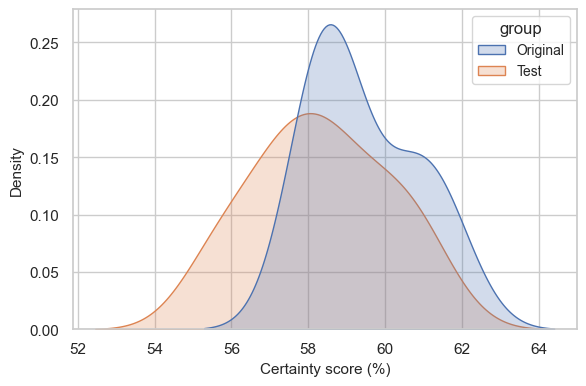

In [26]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x="score", hue="group", fill=True, common_norm=False)
plt.xlabel("Certainty score (%)")
plt.ylabel("Density")
plt.tight_layout()
#plt.savefig("certainty_distribution.png", dpi=300)
plt.show()

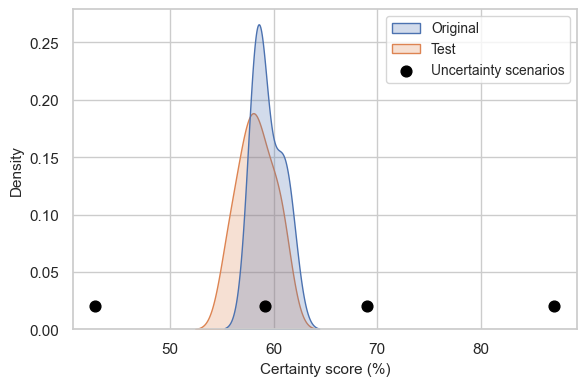

In [27]:
scenario_scores = [87.1, 69.0, 59.2, 42.8]  # 4 scenarios

plt.figure(figsize=(6,4))

ax = sns.kdeplot(data=df, x="score", hue="group", fill=True, common_norm=False)

# Force seaborn to draw its legend first
leg = ax.legend_

# Add your points
scatter = plt.scatter(
    scenario_scores,
    [0.02]*len(scenario_scores),
    color="black",
    s=60,
    zorder=5
)

# --- Rebuild legend properly ---
handles = leg.legend_handles
labels = [t.get_text() for t in leg.texts]

handles.append(scatter)
labels.append("Uncertainty scenarios")

ax.legend(handles=handles, labels=labels)

plt.xlabel("Certainty score (%)")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("certainty_distribution_v2.png", dpi=300)
plt.show()